In [1]:
import os
import cv2
import pandas as pd
from decord import VideoReader, cpu
from tqdm import tqdm

# ==========================================
# 1. Configuration and Directory Setup
# ==========================================
# Define root paths for raw training videos and create a dedicated versioned output directory.
RAW_DATA_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\raw\nexar_collision_prediction\train"
OUTPUT_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\processed\frames_v4"

# Automatically build the target folder hierarchy for dataset splits and classes.
for split in ['train', 'val']:
    for cls in ['accident', 'no_accident']:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

pos_meta_file = os.path.join(RAW_DATA_DIR, "positive", "metadata.csv")
neg_meta_file = os.path.join(RAW_DATA_DIR, "negative", "metadata.csv")

if not os.path.exists(pos_meta_file) or not os.path.exists(neg_meta_file):
    raise FileNotFoundError("One or both metadata.csv files are missing.")

# ==========================================
# 2. Metadata Integration
# ==========================================
# Load separate metadata CSV files for accident and normal driving video classes, then combine them.
print("Loading and merging dataset metadata for V4...")
df_pos = pd.read_csv(pos_meta_file)
df_neg = pd.read_csv(neg_meta_file)
df_metadata = pd.concat([df_pos, df_neg], ignore_index=True)

FRAMES_PER_SECOND_TO_EXTRACT = 2
metadata_records = []

# ==========================================
# 3. Temporal Trimming and Anticipation Logic
# ==========================================
print("Starting V4 temporal frame extraction pipeline (Anticipation Mode)...")

for idx, row in tqdm(df_metadata.iterrows(), total=len(df_metadata)):
    vid_filename = row['file_name']
    label = row.get('label', 1 if 'time_of_event' in row and pd.notna(row['time_of_event']) else 0)
    time_of_event = row.get('time_of_event', None)
    
    folder_name = 'positive' if label == 1 else 'negative'
    vid_path = os.path.join(RAW_DATA_DIR, folder_name, vid_filename)
    
    if not os.path.exists(vid_path):
        continue

    try:
        # Initialize video reader via Decord for CPU-based sequential parsing
        video_reader = VideoReader(vid_path, ctx=cpu(0))
        fps = video_reader.get_avg_fps()
        total_frames = len(video_reader)
        total_duration = total_frames / fps
        
        # Apply anticipation window slicing: isolate pre-event frames for positive samples
        if label == 1 and pd.notna(time_of_event):
            end_time = time_of_event
            start_time = max(0, time_of_event - 4.0)
            class_name = 'accident'
        else:
            # Extract a middle temporal window for normal driving samples
            mid_time = total_duration / 2
            start_time = max(0, mid_time - 2.0)
            end_time = min(total_duration, mid_time + 2.0)
            class_name = 'no_accident'
            
        start_frame = int(start_time * fps)
        end_frame = int(end_time * fps)
        
        step = int(fps / FRAMES_PER_SECOND_TO_EXTRACT)
        if step == 0: 
            step = 1
        
        target_frame_indices = list(range(start_frame, end_frame, step))
        
        # ==========================================
        # 4. Optimized Frame Decoding and Processing
        # ==========================================
        if target_frame_indices:
            # Batch decode targeted frames directly into memory
            frames_array = video_reader.get_batch(target_frame_indices).asnumpy()
            
            # Split data deterministically based on video index
            split_name = 'train' if idx % 5 != 0 else 'val'
            save_dir = os.path.join(OUTPUT_DIR, split_name, class_name)
            
            for i, frame_rgb in enumerate(frames_array):
                # Convert color space and resize frame to standard network dimensions
                frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
                frame_resized = cv2.resize(frame_bgr, (224, 224))
                
                frame_name = f"video_{idx}_f{target_frame_indices[i]}.jpg"
                out_path = os.path.join(save_dir, frame_name)
                cv2.imwrite(out_path, frame_resized)
                
                # Log tracking metadata attributes for generated frames
                metadata_records.append({
                    'video_id': idx,
                    'frame_name': frame_name,
                    'label': label,
                    'split': split_name,
                    'weather': row.get('weather', 'Unknown'),
                    'scene': row.get('scene', 'Unknown'),
                    'light_conditions': row.get('light_conditions', 'Unknown'),
                    'is_event_frame': (label == 1 and pd.notna(time_of_event) and abs((target_frame_indices[i]/fps) - time_of_event) <= 0.5)
                })
    except Exception as e:
        continue

# ==========================================
# 5. Metadata Logging and Export
# ==========================================
# Compile and export tracking records into a unified metadata CSV file
df_meta_clean = pd.DataFrame(metadata_records)
df_meta_clean.to_csv(os.path.join(OUTPUT_DIR, 'extracted_frames_metadata_v4.csv'), index=False)
print("\nFrame extraction pipeline V4 completed successfully.")

Loading and merging dataset metadata for V4...
Starting V4 temporal frame extraction pipeline (Anticipation Mode)...


100%|██████████| 1500/1500 [06:49<00:00,  3.66it/s]


Frame extraction pipeline V4 completed successfully.


In [11]:
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Lambda, TimeDistributed, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Define Paths 
PROCESSED_DATA_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP\data\processed\frames_v4"
CSV_PATH = os.path.join(PROCESSED_DATA_DIR, 'extracted_frames_metadata_v4.csv')

BATCH_SIZE = 8  
SEQ_LENGTH = 8  # Number of consecutive frames per video to feed into LSTM
IMG_HEIGHT, IMG_WIDTH = 224, 224

print("Loading metadata for Sequence Generation...")
df_meta = pd.read_csv(CSV_PATH)
train_df = df_meta[df_meta['split'] == 'train']
val_df = df_meta[df_meta['split'] == 'val']

# 2. Build Custom Video Sequence Generator
class VideoFrameGenerator(Sequence):
    def __init__(self, df, img_dir, batch_size, seq_length, img_height, img_width):
        self.df = df
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.seq_length = seq_length
        self.img_height = img_height
        self.img_width = img_width
        self.video_ids = self.df['video_id'].unique()

    def __len__(self):
        return int(np.floor(len(self.video_ids) / self.batch_size))

    def __getitem__(self, index):
        # Select a batch of video IDs
        batch_vids = self.video_ids[index * self.batch_size:(index + 1) * self.batch_size]
        
        # X shape: (Batch, TimeSteps, Height, Width, Channels)
        X = np.empty((self.batch_size, self.seq_length, self.img_height, self.img_width, 3), dtype=np.float32)
        y = np.empty((self.batch_size), dtype=int)

        for i, vid in enumerate(batch_vids):
            vid_df = self.df[self.df['video_id'] == vid].sort_values(by='frame_name')
            frames = vid_df['frame_name'].tolist()
            label = vid_df['label'].values[0]
            split_folder = vid_df['split'].values[0]
            cls_folder = 'accident' if label == 1 else 'no_accident'

            # Pad or truncate frames to match EXACTLY seq_length
            if len(frames) < self.seq_length:
                frames += [frames[-1]] * (self.seq_length - len(frames))
            else:
                frames = frames[:self.seq_length]

            for j, frame_name in enumerate(frames):
                img_path = os.path.join(self.img_dir, split_folder, cls_folder, frame_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0  # Rescale to 0-1
                    X[i, j,] = img

            y[i] = label

        return X, y

print("Initializing Data Generators...")
train_generator = VideoFrameGenerator(train_df, PROCESSED_DATA_DIR, BATCH_SIZE, SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH)
val_generator = VideoFrameGenerator(val_df, PROCESSED_DATA_DIR, BATCH_SIZE, SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH)

# 3. Define ROI Masking
def roi_mask(x):
    mask = np.ones((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
    mask[:int(IMG_HEIGHT * 0.3), :, :] = 0 
    mask_tensor = tf.constant(mask, dtype=tf.float32)
    return x * mask_tensor

print("Building Model Architecture...")

# 4. Construct the Spatio-Temporal Architecture
# the shape includes SEQ_LENGTH as the temporal dimension
inputs = Input(shape=(SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3))

# Apply mask to EACH frame in the sequence using TimeDistributed
x = TimeDistributed(Lambda(roi_mask, name="roi_mask_layer"))(inputs) 

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), 
    include_top=False, 
    weights='imagenet'
)
# Freeze the base model strictly as advised by the mentor
base_model.trainable = False

# Pass the sequence of frames through the CNN
x = TimeDistributed(base_model, name="td_mobilenetv2")(x, training=False)
x = TimeDistributed(GlobalAveragePooling2D(), name="td_global_avg_pooling")(x)

# 5. Inject LSTM to learn temporal dynamics across frames
x = LSTM(128, return_sequences=False, name="lstm_temporal_encoder")(x)
x = Dropout(0.5, name="dropout_regularization")(x)

outputs = Dense(1, activation='sigmoid', name="binary_classifier")(x)

model = Model(inputs, outputs, name="Nexar_Collision_Predictor_V4_LSTM")

# 6. Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Loading metadata for Sequence Generation...
Initializing Data Generators...
Building Model Architecture...


Model: "Nexar_Collision_Predictor_V4_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 8, 224, 224, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 8, 224, 224, 3) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_mobilenetv2                  │ (None, 8, 7, 7, 1280)  │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_global_avg_pooling           │ (None, 8, 1280)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_temporal_encoder (LSTM)    │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_classifier (Dense)       │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979,521 (11.37 MB)

 Trainable params: 721,537 (2.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# Define MLOps Callbacks
MODEL_SAVE_PATH = "v4_lstm_best_accident_model.keras"

callbacks_list = [
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("Starting model training...")

# train model
EPOCHS = 20

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list
)

print("\nTraining completed successfully!")

Starting model training...
Epoch 1/20


c:\Users\M.Ali\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5808 - auc: 0.6042 - loss: 0.7673
Epoch 1: val_auc improved from None to 0.75110, saving model to v4_lstm_best_accident_model.keras

Epoch 1: finished saving model to v4_lstm_best_accident_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 84s 465ms/step - accuracy: 0.5808 - auc: 0.6042 - loss: 0.7673 - val_accuracy: 0.5068 - val_auc: 0.7511 - val_loss: 0.7065 - learning_rate: 0.0010
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6208 - auc: 0.6608 - loss: 0.6559
Epoch 2: val_auc improved from 0.75110 to 0.75701, saving model to v4_lstm_best_accident_model.keras

Epoch 2: finished saving model to v4_lstm_best_accident_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 76s 507ms/step - accuracy: 0.6208 - auc: 0.6608 - loss: 0.6559 - val_accuracy: 0.6757 - val_auc: 0.7570 - val_loss: 0.6117 - learning_rate: 0.0010
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.6367 - auc: 0.6887 - loss: 0.6388
Epoch 3: val_auc

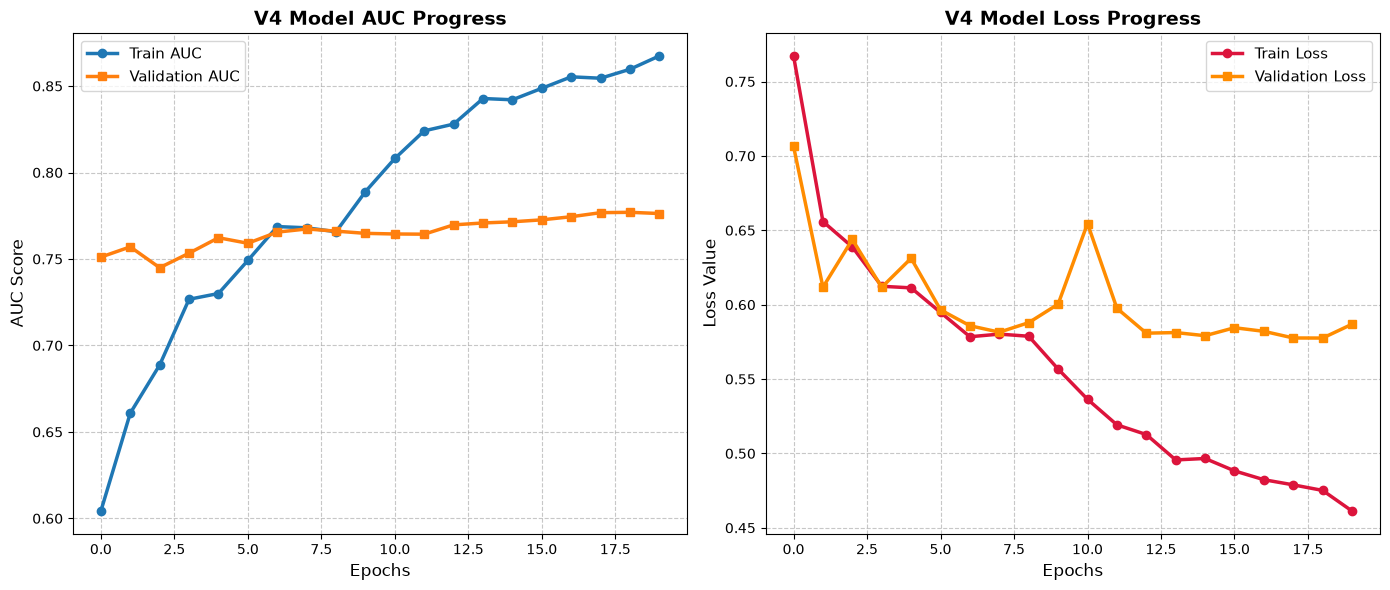

Training performance charts successfully generated and saved as 'v4_training_performance.png'.


In [13]:
import matplotlib.pyplot as plt

# Set the overall figure size for high-resolution layout
plt.figure(figsize=(14, 6))

# 1. Plot AUC Metric (Training vs Validation)
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], label='Train AUC', linewidth=2.5, marker='o')
plt.plot(history.history['val_auc'], label='Validation AUC', linewidth=2.5, marker='s')
plt.title('V4 Model AUC Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Plot Loss Metric (Training vs Validation)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2.5, marker='o', color='crimson')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, marker='s', color='darkorange')
plt.title('V4 Model Loss Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save the high-quality plot for presentation slides
plt.tight_layout()
plt.savefig('v4_training_performance.png', dpi=300)
plt.show()

print("Training performance charts successfully generated and saved as 'v4_training_performance.png'.")

In [15]:
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from decord import VideoReader, cpu
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

print("Initiating Test Set Evaluation for V4...")

# 1. Absolute Paths Setup
BASE_DIR = r"D:\GitHub\QueraAiBootcamp-TeamProject2-ComputerVision&NLP"
TEST_PUB_DIR = os.path.join(BASE_DIR, "data", "raw", "nexar_collision_prediction", "test-public")
TEST_PRIV_DIR = os.path.join(BASE_DIR, "data", "raw", "nexar_collision_prediction", "test-private")
SOLUTION_CSV_PATH = os.path.join(BASE_DIR, "data", "raw", "nexar_collision_prediction", "solution.csv")

MODEL_PATH = "v4_lstm_best_accident_model.keras"  

SEQ_LENGTH = 8
IMG_HEIGHT, IMG_WIDTH = 224, 224

# 2. Load Model Architecture
def roi_mask(x):
    mask = np.ones((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
    mask[:int(IMG_HEIGHT * 0.3), :, :] = 0 
    mask_tensor = tf.constant(mask, dtype=tf.float32)
    return x * mask_tensor

print("Loading V4 Model...")
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'roi_mask': roi_mask})

# 3. Index Test Videos
print("Indexing video paths...")
video_paths = {}
for test_dir in [TEST_PUB_DIR, TEST_PRIV_DIR]:
    for cls in ['positive', 'negative']:
        cls_dir = os.path.join(test_dir, cls)
        if os.path.exists(cls_dir):
            for f in os.listdir(cls_dir):
                if f.endswith('.mp4') or f.endswith('.mkv'):
                    video_paths[f] = os.path.join(cls_dir, f)
                    video_paths[os.path.splitext(f)[0]] = os.path.join(cls_dir, f)

# 4. On-the-fly Video Processor
def process_video_for_eval(vid_path):
    try:
        vr = VideoReader(vid_path, ctx=cpu(0))
        fps = vr.get_avg_fps()
        total_frames = len(vr)
        
        # V4 LOGIC: Extract exactly the last 4 seconds of the test video
        # Since test videos end right before the crash, the last 4 seconds contain the critical pre-crash kinematics.
        window_duration = 4.0
        frames_in_window = int(window_duration * fps)
        
        if total_frames > frames_in_window:
            start_frame = total_frames - frames_in_window
        else:
            start_frame = 0
            
        end_frame = total_frames - 1
        
        # Sample uniformly within this specific 4-second window
        indices = np.linspace(start_frame, end_frame, SEQ_LENGTH, dtype=int)
        frames = vr.get_batch(indices).asnumpy()
        
        X = np.empty((SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
        for i, frame in enumerate(frames):
            frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            frame_resized = cv2.resize(frame_bgr, (IMG_WIDTH, IMG_HEIGHT))
            frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB) / 255.0
            X[i,] = frame_rgb
            
        return np.expand_dims(X, axis=0)
    except Exception:
        return None

# 5. Native Evaluation Loop
print("Evaluating Model on Test Data...")
solution_df = pd.read_csv(SOLUTION_CSV_PATH)

y_true = []
y_pred_probs = []

for idx, row in tqdm(solution_df.iterrows(), total=len(solution_df), desc="Analyzing"):
    vid_id_raw = int(row['id'])
    vid_id = f"{vid_id_raw:05d}"
    target = row['target']  # True label (1 or 0)
    
    vid_path = video_paths.get(vid_id) or video_paths.get(f"{vid_id}.mp4")
    
    if vid_path and os.path.exists(vid_path):
        X_input = process_video_for_eval(vid_path)
        if X_input is not None:
            # Get Probability
            prob = model.predict(X_input, verbose=0)[0][0]
            
            y_true.append(target)
            y_pred_probs.append(prob)

# 6. Calculate Standard Metrics
if len(y_true) > 0:
    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    # Apply 0.5 threshold to convert probabilities to absolute classes (0 or 1)
    y_pred_classes = (y_pred_probs >= 0.5).astype(int)

    # Equivalent to Keras validation metrics
    test_loss = log_loss(y_true, y_pred_probs)
    test_acc = accuracy_score(y_true, y_pred_classes)
    test_auc = roc_auc_score(y_true, y_pred_probs)

    print("\n")
    print("==================================================")
    print("TEST SET PERFORMANCE V4:")
    print("==================================================")
    print(f" Test Loss : {test_loss:.4f}")
    print(f" Test Accuracy                   : {test_acc:.4f} ({(test_acc*100):.2f}%)")
    print(f" Test AUC (ROC)                  : {test_auc:.4f}")
    print("==================================================")
else:
    print("\n❌ EVALUATION FAILED: No valid samples processed.")

Initiating Test Set Evaluation for V4...
Loading V4 Model...
Indexing video paths...
Evaluating Model on Test Data...


Analyzing: 100%|██████████| 1344/1344 [06:38<00:00,  3.38it/s]



TEST SET PERFORMANCE V4:
 Test Loss : 0.5872
 Test Accuracy                   : 0.6905 (69.05%)
 Test AUC (ROC)                  : 0.7656
